In [1]:
from torch.distributions import Poisson, Normal, MultivariateNormal
from gpzoo.gp import SVGP, MGGP_SVGP, VNNGP, MGGP_WSVGP, MGGP_VNNGP
from gpzoo.kernels import batched_RBF, batched_MGGP_RBF
from gpzoo.utilities import build_sparse_from_Kzx_knnidx, symmetrize_by_copy, add_jitter
import torch
import matplotlib.pyplot as plt

/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/gpzoo/utilities.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
N = 50

In [3]:
X1 = torch.linspace(-2, 2, N)[:, None]
groupsX1 = torch.zeros_like(X1.squeeze()).type(torch.long)
X2 = torch.linspace(-2, 2, N)[:, None]
groupsX2 = torch.ones_like(X2.squeeze()).type(torch.long)
X = torch.cat((X1, X2))
groupsX = torch.cat((groupsX1, groupsX2)).squeeze().type(torch.long)

In [47]:
K=40

n_groups = 2
M = 2*N


kernel = batched_MGGP_RBF(sigma=1.0, lengthscale=0.4, group_diff_param=1.0)
full_kernel = kernel.forward(X, X, groupsX, groupsX)
gp = MGGP_VNNGP(kernel, dim=1, M=M, n_groups=n_groups, jitter=1e-5, K=K)


gp.Z = torch.nn.Parameter(X)
gp.groupsZ = torch.nn.Parameter( groupsX, requires_grad=False)
gp.mu = torch.nn.Parameter(torch.zeros(2*N))



knn_idx = gp.calculate_knn(X)
gp.knn_idx = knn_idx[:, :-1]
gp.knn_idz= knn_idx[:, 1:]



Kxx, Kzx, Kzz = gp.forward_kernels(X, groupsX)
A = build_sparse_from_Kzx_knnidx(Kzx, knn_idx[:,:-1], 2*N)
A = symmetrize_by_copy(A)
U, S, V = torch.svd_lowrank(A, q=M, niter=K)
U, S, V = torch.svd(A.to_dense())

W = U*(S**0.5).detach()
gp.Lu = torch.nn.Parameter(W)

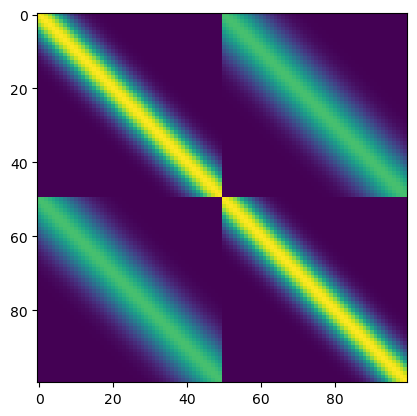

In [48]:
plt.imshow(full_kernel.detach(), vmin=0.0, vmax=1.0)

In [216]:
full_precision.max()

tensor(17027748., grad_fn=<MaxBackward1>)

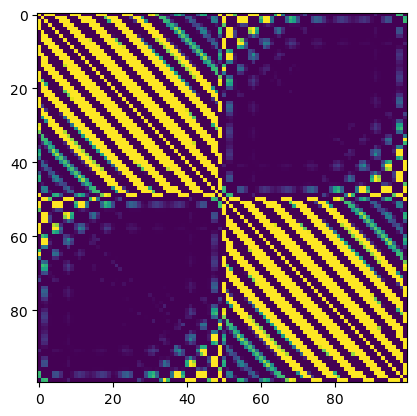

In [219]:
full_precision = torch.inverse(add_jitter(full_kernel.contiguous(), 1e-3))
plt.imshow(full_precision.detach(), vmin=0.0, vmax=1.0)

In [220]:
L_p = torch.linalg.cholesky(full_precision)

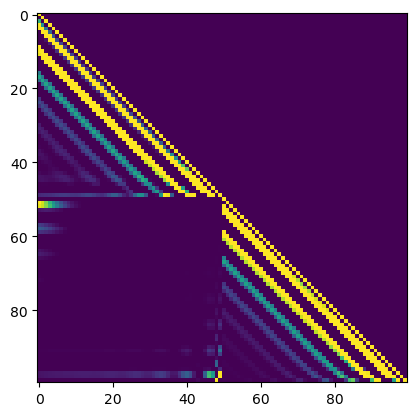

In [221]:
plt.imshow(L_p.detach(), vmin=0, vmax=1.0)

In [193]:
L = torch.linalg.cholesky(add_jitter(full_kernel.contiguous(), 1e-6))

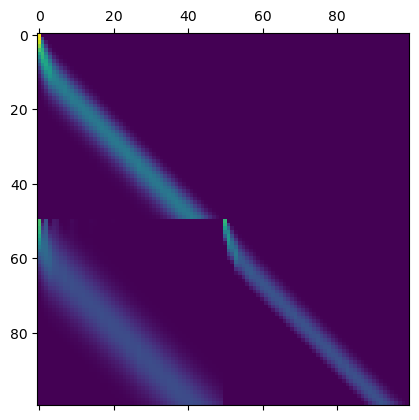

In [194]:
plt.matshow(L.detach(), vmax=1, vmin=0.0)

In [195]:
n = L.shape[0]
I = torch.eye(n, dtype=L.dtype, device=L.device)

R= torch.linalg.solve_triangular(L, I, upper=False)

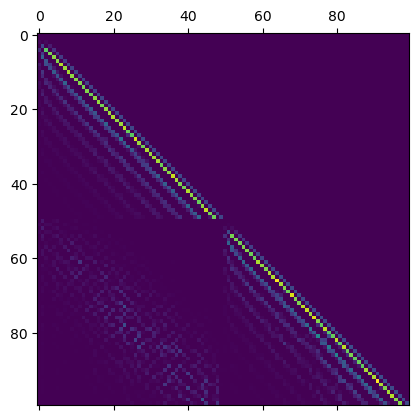

In [204]:
plt.matshow(R.detach(),  vmin=0, vmax=R.max())

In [168]:
nugget = torch.randn(len(L))
rand_vector = (L@nugget).detach()

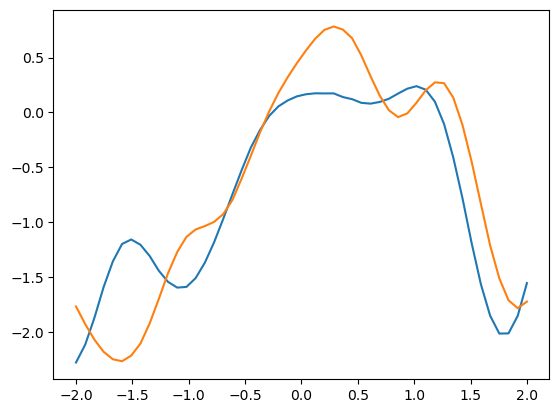

In [70]:
plt.plot(X1, rand_vector[:N])
plt.plot(X2, rand_vector[N:])

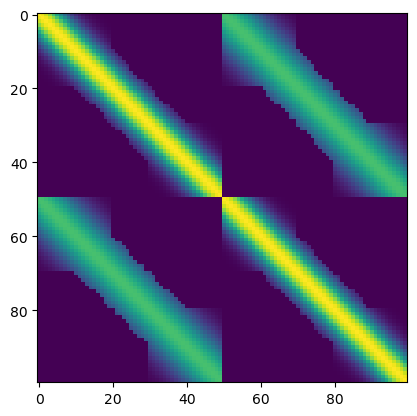

In [72]:
plt.imshow(A.to_dense().detach(), vmin=0.0, vmax=1.0)

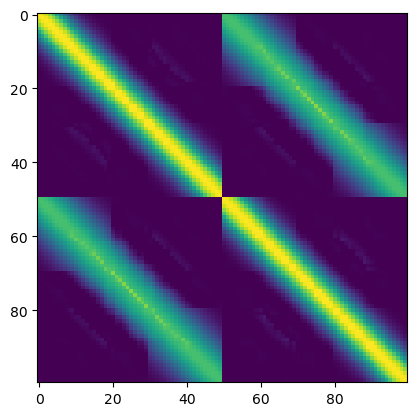

In [46]:
plt.imshow((W@W.T).detach(), vmin=0.0, vmax=1.0)